# Week 1 — Introduction to Machine Learning

**Syllabus topics:** What machine learning is and why · supervised and unsupervised learning · polynomial curve fitting · probability theory: discrete random variables, fundamental rules, Bayes rule, independence and conditional independence, continuous random variables, quantiles, mean and variance, probability densities, expectation and covariance.

Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Theory — Machine learning: what and why? Supervised and unsupervised learning

Machine learning means learning a rule from examples instead of writing it by hand. With answers attached to the examples it is supervised; without answers, the algorithm can only group similar examples (unsupervised).

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from weather import load, split, FEATURES

train, test = split(load())

# Supervised: every training day comes with the answer "did it rain the next day?"
model = LogisticRegression(max_iter=1000).fit(train[FEATURES], train.rain_tomorrow)
print("SUPERVISED   learned from labelled days; accuracy on the unseen year 2015 =", round(model.score(test[FEATURES], test.rain_tomorrow), 3))

# Unsupervised: no answers at all; the algorithm only groups days that look alike
X = train[["temp_max", "temp_min", "wind", "precipitation"]]
group = KMeans(3, n_init=10, random_state=0).fit_predict((X - X.mean()) / X.std())
print("UNSUPERVISED found 3 groups of days, with sizes", np.bincount(group).tolist(), "\n")
print(X.assign(group=group).groupby("group").mean().round(1))

SUPERVISED   learned from labelled days; accuracy on the unseen year 2015 = 0.728
UNSUPERVISED found 3 groups of days, with sizes [467, 399, 230] 

       temp_max  temp_min  wind  precipitation
group                                         
0          23.1      12.5   2.8            0.6
1          10.2       3.5   2.7            1.3
2          12.1       6.8   5.1           10.8


## Theory — Polynomial curve fitting

Fit curves of growing degree to 25 days of temperature. A flexible curve matches the training days perfectly but misses the unseen days (over-fitting).

degree  train RMSE  test RMSE (2015)
     0        6.32       7.64
     1        5.94       7.76
     2        3.72       4.99
     3        3.24       4.64
     4        3.13       4.41
     5        2.77       4.46
     6        2.71       4.58
     7        2.62       4.59
     8        2.62       4.56
     9        2.56       4.66
    10        2.50       6.39


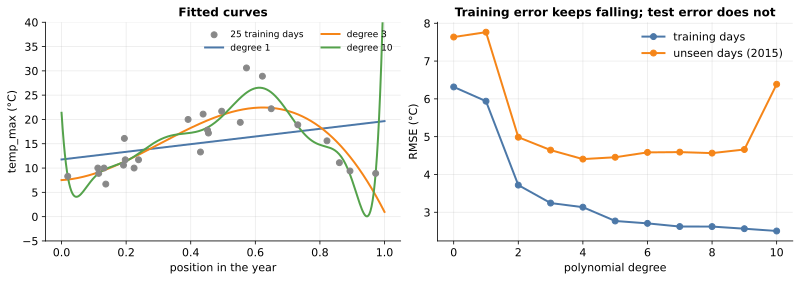

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load, split

train, test = split(load())
pick = train.sample(25, random_state=1)                      # a small training set makes over-fitting easy to see
t = lambda df: df.date.dt.dayofyear.values / 365             # position in the year, 0 to 1
fit = lambda degree: np.polynomial.Polynomial.fit(t(pick), pick.temp_max, degree)
rmse = lambda curve, df: np.sqrt(np.mean((df.temp_max - curve(t(df))) ** 2))

degrees = range(0, 11)
train_err = [rmse(fit(k), pick) for k in degrees]
test_err = [rmse(fit(k), test) for k in degrees]
print("degree  train RMSE  test RMSE (2015)")
for k in degrees:
    print(f"{k:>6}  {train_err[k]:>10.2f}  {test_err[k]:>9.2f}")

grid = np.linspace(0, 1, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(t(pick), pick.temp_max, color="#888", zorder=3, label="25 training days")
for k in [1, 3, 10]:
    ax[0].plot(grid, fit(k)(grid), label=f"degree {k}")
ax[0].set_ylim(-5, 40); ax[0].set_xlabel("position in the year"); ax[0].set_ylabel("temp_max (°C)")
ax[0].set_title("Fitted curves"); ax[0].legend(loc="upper right", ncol=2, fontsize=9)
ax[1].plot(degrees, train_err, "o-", label="training days"); ax[1].plot(degrees, test_err, "o-", label="unseen days (2015)")
ax[1].set_xlabel("polynomial degree"); ax[1].set_ylabel("RMSE (°C)"); ax[1].set_title("Training error keeps falling; test error does not"); ax[1].legend()
plt.show()

## Theory — Discrete random variables, fundamental rules and Bayes' rule

Today's weather and tomorrow's weather are two discrete random variables (rain or dry). We count their joint table, then check the sum rule, the product rule and Bayes' rule.

Joint probability P(today, tomorrow):
            dry tomorrow  rain tomorrow
dry today          0.434          0.140
rain today         0.140          0.287 

Sum rule      P(rain tomorrow) = 0.427
Product rule  P(b|a) x P(a) rebuilds the joint table: True 

Conditional probability P(tomorrow | today):
            dry tomorrow  rain tomorrow
dry today          0.756          0.244
rain today         0.327          0.673 

Bayes' rule gives P(rain today | rain tomorrow) = 0.673; counting it directly gives 0.673


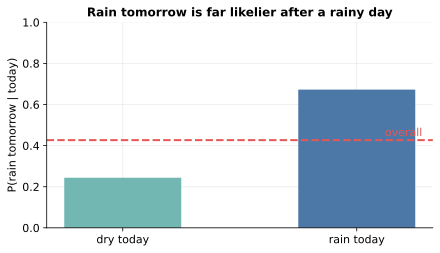

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

t = load().dropna()
joint = pd.crosstab(t.rain, t.rain_tomorrow, normalize=True)       # P(today, tomorrow)
joint.index, joint.columns = ["dry today", "rain today"], ["dry tomorrow", "rain tomorrow"]
print("Joint probability P(today, tomorrow):"); print(joint.round(3), "\n")

p_today, p_tomorrow = joint.sum(axis=1), joint.sum(axis=0)          # sum rule: add up over the other variable
print("Sum rule      P(rain tomorrow) =", round(p_tomorrow["rain tomorrow"], 3))
cond = joint.div(p_today, axis=0)                                   # product rule: P(a, b) = P(b | a) P(a)
print("Product rule  P(b|a) x P(a) rebuilds the joint table:", np.allclose(cond.mul(p_today, axis=0), joint), "\n")
print("Conditional probability P(tomorrow | today):"); print(cond.round(3), "\n")

# Bayes' rule turns it around: P(rain today | rain tomorrow) = P(rain tomorrow | rain today) P(rain today) / P(rain tomorrow)
bayes = cond.loc["rain today", "rain tomorrow"] * p_today["rain today"] / p_tomorrow["rain tomorrow"]
direct = joint.loc["rain today", "rain tomorrow"] / p_tomorrow["rain tomorrow"]
print(f"Bayes' rule gives P(rain today | rain tomorrow) = {bayes:.3f}; counting it directly gives {direct:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(["dry today", "rain today"], cond["rain tomorrow"], color=["#72b7b2", "#4c78a8"], width=.5)
ax.axhline(p_tomorrow["rain tomorrow"], color="#e45756", ls="--"); ax.set_ylim(0, 1)
ax.set_title("Rain tomorrow is far likelier after a rainy day"); ax.set_ylabel("P(rain tomorrow | today)")
ax.text(1.28, p_tomorrow["rain tomorrow"] + .02, "overall", color="#e45756", ha="right"); plt.show()

## Theory — Independence and conditional independence

A and B are independent when P(A, B) = P(A) P(B). Rain today and rain tomorrow are not. Rain on day 1 and day 3 are linked only through day 2, so they are (nearly) independent once day 2 is known.

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from weather import load

r = load().rain
a, b, c = r.values[:-2], r.values[1:-1], r.values[2:]      # rain on day 1, day 2 and day 3
def p_value(x, y):
    return chi2_contingency(pd.crosstab(x, y))[1]

print(f"P(rain day 2)                       = {b.mean():.3f}")
print(f"P(rain day 2 | rain day 1)          = {b[a == 1].mean():.3f}   -> not equal, so dependent (chi-square p = {p_value(a, b):.1e})\n")
gap = lambda m: c[m & (a == 1)].mean() - c[m & (a == 0)].mean()       # how much does day 1 change the chance of rain on day 3?
everything = np.ones(len(a), dtype=bool)
print(f"Day 1 and day 3 on their own: rain on day 1 raises the chance of rain on day 3 by {gap(everything):.2f}  (chi-square p = {p_value(a, c):.1e})")
print("Now fix day 2 and look at that gap again:")
for v, name in [(1, "rain"), (0, "dry")]:
    print(f"  day 2 = {name}:  gap = {gap(b == v):.2f}   (p = {p_value(a[b == v], c[b == v]):.2g})")
print("\nWhen day 2 was rainy the gap almost vanishes (conditionally independent). When day 2 was dry it only shrinks:")
print("weather has some longer memory, so 'tomorrow depends only on today' is a good approximation, not an exact truth.")

P(rain day 2)                       = 0.427
P(rain day 2 | rain day 1)          = 0.673   -> not equal, so dependent (chi-square p = 7.7e-60)

Day 1 and day 3 on their own: rain on day 1 raises the chance of rain on day 3 by 0.29  (chi-square p = 1.0e-28)
Now fix day 2 and look at that gap again:
  day 2 = rain:  gap = 0.02   (p = 0.62)
  day 2 = dry:  gap = 0.23   (p = 5.2e-11)

When day 2 was rainy the gap almost vanishes (conditionally independent). When day 2 was dry it only shrinks:
weather has some longer memory, so 'tomorrow depends only on today' is a good approximation, not an exact truth.


## Theory — Continuous random variables: probability density, quantiles, mean and variance

The daily highest temperature is a continuous random variable. We estimate its density, its cumulative distribution and its quantiles, and compare with a normal curve.

mean = 16.44 °C | variance = 54.02 | standard deviation = 7.35 °C
quantiles  5% / 25% / 50% / 75% / 95%: [6.1, 10.6, 15.6, 22.2, 28.9] °C
P(temp_max > 25 °C): counted = 0.144 | from a normal curve = 0.122


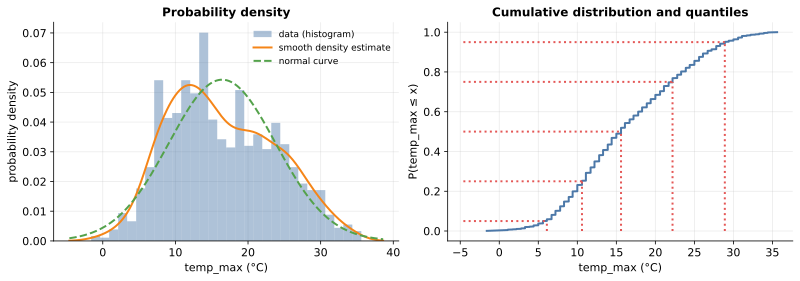

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from weather import load

x = load().temp_max.values
mean, var = x.mean(), x.var(ddof=1)
q = np.quantile(x, [.05, .25, .5, .75, .95])
print(f"mean = {mean:.2f} °C | variance = {var:.2f} | standard deviation = {np.sqrt(var):.2f} °C")
print("quantiles  5% / 25% / 50% / 75% / 95%:", q.round(1).tolist(), "°C")
print(f"P(temp_max > 25 °C): counted = {(x > 25).mean():.3f} | from a normal curve = {1 - stats.norm.cdf(25, mean, np.sqrt(var)):.3f}")

grid = np.linspace(x.min() - 3, x.max() + 3, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(x, bins=30, density=True, alpha=.45, label="data (histogram)")
ax[0].plot(grid, stats.gaussian_kde(x)(grid), label="smooth density estimate")
ax[0].plot(grid, stats.norm.pdf(grid, mean, np.sqrt(var)), "--", label="normal curve")
ax[0].set_xlabel("temp_max (°C)"); ax[0].set_ylabel("probability density"); ax[0].set_title("Probability density"); ax[0].legend(fontsize=9)
ax[1].plot(np.sort(x), np.arange(1, len(x) + 1) / len(x))
for p, v in zip([.05, .25, .5, .75, .95], q):
    ax[1].plot([v, v], [0, p], ":", color="#e45756"); ax[1].plot([x.min() - 3, v], [p, p], ":", color="#e45756")
ax[1].set_xlabel("temp_max (°C)"); ax[1].set_ylabel("P(temp_max ≤ x)"); ax[1].set_title("Cumulative distribution and quantiles")
plt.show()

## Theory — Expectation and covariance

The expectation E[X] is the average value; the covariance Cov(X, Y) = E[XY] - E[X]E[Y] says whether two variables rise together.

Expectation E[X] of each variable: {'precipitation': 3.03, 'temp_max': 16.44, 'temp_min': 8.23, 'wind': 3.24}
E[temp_max²] - E[temp_max]² equals the variance: 53.98 = 53.98 

Covariance matrix:
[[ 44.62 -11.22  -2.44   3.15]
 [-11.22  54.02  32.33  -1.74]
 [ -2.44  32.33  25.23  -0.54]
 [  3.15  -1.74  -0.54   2.07]]

Cov(temp_max, temp_min) = E[XY] - E[X]E[Y] = 32.31 (matches the matrix entry 32.33 up to the n vs n-1 divisor)


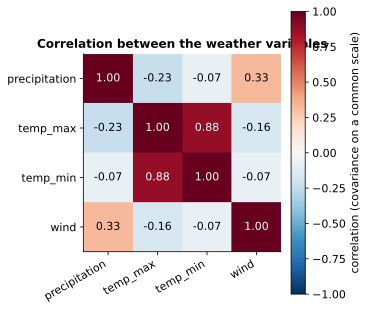

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load

d = load()
cols = ["precipitation", "temp_max", "temp_min", "wind"]
X = d[cols].values
print("Expectation E[X] of each variable:", dict(zip(cols, X.mean(0).round(2).tolist())))
print("E[temp_max²] - E[temp_max]² equals the variance:", round((X[:, 1] ** 2).mean() - X[:, 1].mean() ** 2, 2), "=", round(X[:, 1].var(), 2), "\n")

cov = np.cov(X, rowvar=False)
manual = (X[:, 1] * X[:, 2]).mean() - X[:, 1].mean() * X[:, 2].mean()
print("Covariance matrix:"); print(np.round(cov, 2))
print("\nCov(temp_max, temp_min) = E[XY] - E[X]E[Y] =", round(manual, 2), "(matches the matrix entry", round(cov[1, 2], 2), "up to the n vs n-1 divisor)")

corr = np.corrcoef(X, rowvar=False)
fig, ax = plt.subplots(figsize=(5, 4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(4), cols, rotation=30, ha="right"); ax.set_yticks(range(4), cols)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="white" if abs(corr[i, j]) > .6 else "black")
fig.colorbar(im, label="correlation (covariance on a common scale)"); ax.set_title("Correlation between the weather variables"); plt.show()

## Practice 1 — Devise a program to import, load and view the dataset

Read the CSV file into a table, then look at its size, its column types and its first rows.

In [8]:
from weather import load

d = load()                                          # reads data/seattle_weather.csv
raw = d[["date", "precipitation", "temp_max", "temp_min", "wind", "weather"]]
print("rows, columns:", raw.shape)
print("period:", d.date.min().date(), "to", d.date.max().date(), "\n")
print(raw.dtypes, "\n")
print(raw.head(10).to_string(index=False))
print("\nWeather labels:", d.weather.value_counts().to_dict())

rows, columns: (1461, 6)
period: 2012-01-01 to 2015-12-31 

date             datetime64[us]
precipitation           float64
temp_max                float64
temp_min                float64
wind                    float64
weather                     str
dtype: object 

      date  precipitation  temp_max  temp_min  wind weather
2012-01-01            0.0      12.8       5.0   4.7 drizzle
2012-01-02           10.9      10.6       2.8   4.5    rain
2012-01-03            0.8      11.7       7.2   2.3    rain
2012-01-04           20.3      12.2       5.6   4.7    rain
2012-01-05            1.3       8.9       2.8   6.1    rain
2012-01-06            2.5       4.4       2.2   2.2    rain
2012-01-07            0.0       7.2       2.8   2.3    rain
2012-01-08            0.0      10.0       2.8   2.0     sun
2012-01-09            4.3       9.4       5.0   3.4    rain
2012-01-10            1.0       6.1       0.6   3.4    rain

Weather labels: {'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 's

## Practice 2 — Create a program to display the summary and statistics of the dataset

Summary statistics, missing values and skew, then histograms and the yearly cycle.

       precipitation  temp_max  temp_min     wind
count        1461.00   1461.00   1461.00  1461.00
mean            3.03     16.44      8.23     3.24
std             6.68      7.35      5.02     1.44
min             0.00     -1.60     -7.10     0.40
25%             0.00     10.60      4.40     2.20
50%             0.00     15.60      8.30     3.00
75%             2.80     22.20     12.20     4.00
max            55.90     35.60     18.30     9.50 

missing values per column: {'precipitation': 0, 'temp_max': 0, 'temp_min': 0, 'wind': 0, 'weather': 0}
skewness: {'precipitation': 3.51, 'temp_max': 0.28, 'temp_min': -0.25, 'wind': 0.89} (precipitation is strongly right-skewed)


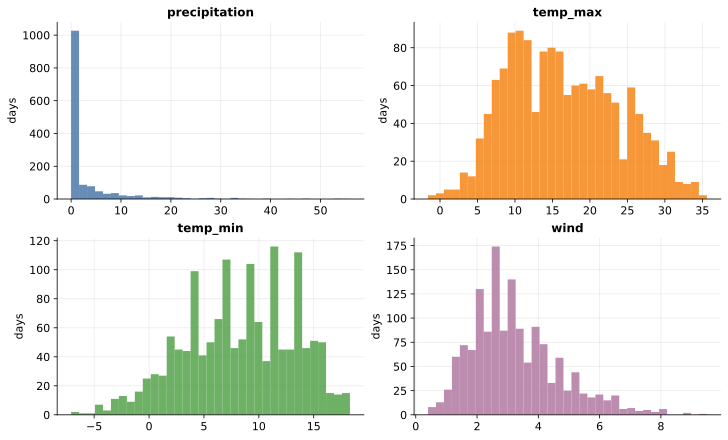

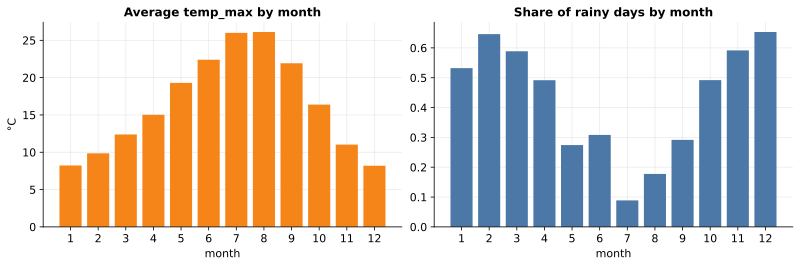

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from weather import load

d = load()
cols = ["precipitation", "temp_max", "temp_min", "wind"]
print(d[cols].describe().round(2), "\n")
print("missing values per column:", d[cols + ["weather"]].isna().sum().to_dict())
print("skewness:", d[cols].skew().round(2).to_dict(), "(precipitation is strongly right-skewed)")

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
for a, c, colour in zip(ax.ravel(), cols, ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]):
    a.hist(d[c], bins=35, color=colour, alpha=.85); a.set_title(c); a.set_ylabel("days")
plt.show()

monthly = d.groupby(d.date.dt.month).agg(temp_max=("temp_max", "mean"), rain_share=("rain", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(monthly.index, monthly.temp_max, color="#f58518"); ax[0].set_title("Average temp_max by month"); ax[0].set_ylabel("°C")
ax[1].bar(monthly.index, monthly.rain_share, color="#4c78a8"); ax[1].set_title("Share of rainy days by month")
for a in ax: a.set_xlabel("month"); a.set_xticks(range(1, 13))
plt.show()